In [ ]:
!pip install pyspark

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Big Data Analysis") \
    .getOrCreate()

print("PySpark started successfully!")

PySpark started successfully!


# E-commerce Customer Behaviour and Sales Analysis Using PySpark

## Introduction

This project focuses on analyzing a large e-commerce dataset using Apache PySpark.
The aim is to process large volumes of customer and sales data efficiently and
identify meaningful patterns related to customer behaviour, product performance,
sales trends, and purchasing patterns.

## Problem Statement

E-commerce platforms generate large amounts of data through customer orders,
products, transactions, and purchasing activities. Analyzing such large datasets
using traditional methods can be time-consuming. This project uses PySpark to
process and analyze the data efficiently and extract useful business insights.

## Objectives

- Process a large e-commerce dataset using PySpark.
- Understand customer purchasing behaviour.
- Analyze product and category performance.
- Identify sales trends and patterns.
- Analyze order and transaction information.
- Identify high-value customers and purchasing patterns.
- Generate meaningful insights from large-scale data.

## Technology Used

- Python
- Apache PySpark
- Google Colab
- Pandas
- Matplotlib

## Expected Outcome

The project will demonstrate how PySpark can be used to process and analyze
large-scale e-commerce data and generate meaningful insights that can support
better understanding of customers, products, and sales performance.

In [ ]:
# Check that PySpark is working
print("Spark version:", spark.version)

Spark version: 4.0.4


In [ ]:
# Download the required Olist e-commerce datasets directly

base_url = "https://raw.githubusercontent.com/fortunewalla/olist/main/"

files = [
    "olist_orders_dataset.csv",
    "olist_order_items_dataset.csv",
    "olist_order_payments_dataset.csv",
    "olist_order_reviews_dataset.csv",
    "olist_products_dataset.csv",
    "olist_customers_dataset.csv",
    "olist_sellers_dataset.csv",
    "product_category_name_translation.csv"
]

import requests

for file in files:
    url = base_url + file
    response = requests.get(url)

    if response.status_code == 200:
        with open(file, "wb") as f:
            f.write(response.content)
        print("Downloaded:", file)
    else:
        print("Failed:", file)

print("\nAll required files downloaded!")

Failed: olist_orders_dataset.csv
Failed: olist_order_items_dataset.csv
Failed: olist_order_payments_dataset.csv
Failed: olist_order_reviews_dataset.csv
Failed: olist_products_dataset.csv
Failed: olist_customers_dataset.csv
Failed: olist_sellers_dataset.csv
Failed: product_category_name_translation.csv

All required files downloaded!


In [ ]:
# Download all required Olist datasets from the official Olist repository

base_url = "https://raw.githubusercontent.com/olist/work-at-olist-data/master/datasets/"

files = [
    "olist_orders_dataset.csv",
    "olist_order_items_dataset.csv",
    "olist_order_payments_dataset.csv",
    "olist_order_reviews_dataset.csv",
    "olist_products_dataset.csv",
    "olist_customers_dataset.csv",
    "olist_sellers_dataset.csv",
    "product_category_name_translation.csv"
]

import requests

for file in files:
    url = base_url + file
    response = requests.get(url)

    if response.status_code == 200:
        with open(file, "wb") as f:
            f.write(response.content)
        print("Downloaded:", file)
    else:
        print("FAILED:", file, "Status:", response.status_code)

print("\nDownload process completed!")

Downloaded: olist_orders_dataset.csv
Downloaded: olist_order_items_dataset.csv
Downloaded: olist_order_payments_dataset.csv
Downloaded: olist_order_reviews_dataset.csv
Downloaded: olist_products_dataset.csv
Downloaded: olist_customers_dataset.csv
Downloaded: olist_sellers_dataset.csv
Downloaded: product_category_name_translation.csv

Download process completed!


In [ ]:
# Load the e-commerce datasets into PySpark

orders = spark.read.csv("olist_orders_dataset.csv", header=True, inferSchema=True)
order_items = spark.read.csv("olist_order_items_dataset.csv", header=True, inferSchema=True)
payments = spark.read.csv("olist_order_payments_dataset.csv", header=True, inferSchema=True)
reviews = spark.read.csv("olist_order_reviews_dataset.csv", header=True, inferSchema=True)
products = spark.read.csv("olist_products_dataset.csv", header=True, inferSchema=True)
customers = spark.read.csv("olist_customers_dataset.csv", header=True, inferSchema=True)
sellers = spark.read.csv("olist_sellers_dataset.csv", header=True, inferSchema=True)
category_translation = spark.read.csv(
    "product_category_name_translation.csv",
    header=True,
    inferSchema=True
)

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [ ]:
# Check the size of each dataset

print("Orders:", orders.count())
print("Order Items:", order_items.count())
print("Payments:", payments.count())
print("Reviews:", reviews.count())
print("Products:", products.count())
print("Customers:", customers.count())
print("Sellers:", sellers.count())
print("Category Translation:", category_translation.count())

Orders: 99441
Order Items: 112650
Payments: 103886
Reviews: 104162
Products: 32951
Customers: 99441
Sellers: 3095
Category Translation: 71


In [ ]:
# Display the columns of each dataset

print("ORDERS COLUMNS:")
print(orders.columns)

print("\nORDER ITEMS COLUMNS:")
print(order_items.columns)

print("\nPAYMENTS COLUMNS:")
print(payments.columns)

print("\nREVIEWS COLUMNS:")
print(reviews.columns)

print("\nPRODUCTS COLUMNS:")
print(products.columns)

print("\nCUSTOMERS COLUMNS:")
print(customers.columns)

print("\nSELLERS COLUMNS:")
print(sellers.columns)

ORDERS COLUMNS:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

ORDER ITEMS COLUMNS:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

PAYMENTS COLUMNS:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

REVIEWS COLUMNS:
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

PRODUCTS COLUMNS:
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

CUSTOMERS COLUMNS:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

SELLERS COLUMNS:
['seller_id', 'seller_zip_code_prefix'

In [ ]:
# Preview the orders dataset

orders.show(5, truncate=False)

+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|order_id                        |customer_id                     |order_status|order_purchase_timestamp|order_approved_at  |order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|e481f51cbdc54678b7cc49136f2d6af7|9ef432eb6251297304e76186b10a928d|delivered   |2017-10-02 10:56:33     |2017-10-02 11:07:15|2017-10-04 19:55:00         |2017-10-10 21:25:13          |2017-10-18 00:00:00          |
|53cdb2fc8bc7dce0b6741e2150273451|b0830fb4747a6c6d20dea0b8c802d7ef|delivered   |2018-07-24 20:41:37     |2018-07-26 03:24:27|2018-07-26 14:3

In [ ]:
# Analyze order status distribution

order_status_analysis = orders.groupBy("order_status") \
    .count() \
    .orderBy("count", ascending=False)

order_status_analysis.show()


+------------+-----+
|order_status|count|
+------------+-----+
|   delivered|96478|
|     shipped| 1107|
|    canceled|  625|
| unavailable|  609|
|    invoiced|  314|
|  processing|  301|
|     created|    5|
|    approved|    2|
+------------+-----+



In [ ]:
# Analyze payment methods

payment_method_analysis = payments.groupBy("payment_type") \
    .count() \
    .orderBy("count", ascending=False)

payment_method_analysis.show()

+------------+-----+
|payment_type|count|
+------------+-----+
| credit_card|76795|
|      boleto|19784|
|     voucher| 5775|
|  debit_card| 1529|
| not_defined|    3|
+------------+-----+



In [ ]:
from pyspark.sql.functions import sum

# Analyze total payment value by payment method

payment_value_analysis = payments.groupBy("payment_type") \
    .agg(sum("payment_value").alias("total_payment_value")) \
    .orderBy("total_payment_value", ascending=False)

payment_value_analysis.show()

+------------+-------------------+
|payment_type|total_payment_value|
+------------+-------------------+
| credit_card| 1.25420841899995E7|
|      boleto|  2869361.269999996|
|     voucher| 379436.87000000064|
|  debit_card| 217989.79000000015|
| not_defined|                0.0|
+------------+-------------------+



In [ ]:
# Analyze the most frequently sold products

top_products = order_items.groupBy("product_id") \
    .count() \
    .orderBy("count", ascending=False) \
    .limit(10)

top_products.show()

+--------------------+-----+
|          product_id|count|
+--------------------+-----+
|aca2eb7d00ea1a7b8...|  527|
|99a4788cb24856965...|  488|
|422879e10f4668299...|  484|
|389d119b48cf3043d...|  392|
|368c6c730842d7801...|  388|
|53759a2ecddad2bb8...|  373|
|d1c427060a0f73f6b...|  343|
|53b36df67ebb7c415...|  323|
|154e7e31ebfa09220...|  281|
|3dd2a17168ec895c7...|  274|
+--------------------+-----+



In [ ]:
from pyspark.sql.functions import sum, col

# Join order items with product information
product_sales = order_items.join(
    products,
    on="product_id",
    how="inner"
)

# Calculate number of items sold by product category
category_sales = product_sales.groupBy("product_category_name") \
    .agg(
        sum("price").alias("total_sales"),
        __import__("pyspark").sql.functions.count("order_item_id").alias("items_sold")
    ) \
    .orderBy("total_sales", ascending=False)

category_sales.show(10, truncate=False)

+----------------------+------------------+----------+
|product_category_name |total_sales       |items_sold|
+----------------------+------------------+----------+
|beleza_saude          |1258681.3400000173|9670      |
|relogios_presentes    |1205005.6800000127|5991      |
|cama_mesa_banho       |1036988.6800000386|11115     |
|esporte_lazer         |988048.9700000195 |8641      |
|informatica_acessorios|911954.3200000152 |7827      |
|moveis_decoracao      |729762.4900000072 |8334      |
|cool_stuff            |635290.849999994  |3796      |
|utilidades_domesticas |632248.6600000006 |6964      |
|automotivo            |592720.109999998  |4235      |
|ferramentas_jardim    |485256.459999998  |4347      |
+----------------------+------------------+----------+
only showing top 10 rows


In [ ]:
# Translate product categories into English

category_sales_english = category_sales.join(
    category_translation,
    category_sales.product_category_name == category_translation.product_category_name,
    "left"
).select(
    category_sales.product_category_name,
    category_translation.product_category_name_english,
    category_sales.total_sales,
    category_sales.items_sold
).orderBy("total_sales", ascending=False)

category_sales_english.show(10, truncate=False)

+----------------------+-----------------------------+------------------+----------+
|product_category_name |product_category_name_english|total_sales       |items_sold|
+----------------------+-----------------------------+------------------+----------+
|beleza_saude          |health_beauty                |1258681.3400000173|9670      |
|relogios_presentes    |watches_gifts                |1205005.6800000127|5991      |
|cama_mesa_banho       |bed_bath_table               |1036988.6800000386|11115     |
|esporte_lazer         |sports_leisure               |988048.9700000195 |8641      |
|informatica_acessorios|computers_accessories        |911954.3200000152 |7827      |
|moveis_decoracao      |furniture_decor              |729762.4900000072 |8334      |
|cool_stuff            |cool_stuff                   |635290.849999994  |3796      |
|utilidades_domesticas |housewares                   |632248.6600000006 |6964      |
|automotivo            |auto                         |592720.1099

In [ ]:
from pyspark.sql.functions import to_timestamp, date_format

# Convert order purchase timestamp into a proper date
orders_with_date = orders.withColumn(
    "purchase_date",
    to_timestamp("order_purchase_timestamp")
)

# Join orders with order items
sales_by_month = order_items.join(
    orders_with_date.select("order_id", "purchase_date"),
    on="order_id",
    how="inner"
)

# Calculate monthly sales
monthly_sales = sales_by_month.withColumn(
    "month",
    date_format("purchase_date", "yyyy-MM")
).groupBy("month").agg(
    sum("price").alias("total_sales")
).orderBy("month")

monthly_sales.show(20, truncate=False)

+-------+------------------+
|month  |total_sales       |
+-------+------------------+
|2016-09|267.36            |
|2016-10|49507.66000000009 |
|2016-12|10.9              |
|2017-01|120312.87000000032|
|2017-02|247303.0199999985 |
|2017-03|374344.29999999516|
|2017-04|359927.2299999956 |
|2017-05|506071.1399999948 |
|2017-06|433038.5999999939 |
|2017-07|498031.4799999967 |
|2017-08|573971.6799999981 |
|2017-09|624401.6899999977 |
|2017-10|664219.4299999973 |
|2017-11|1010271.3700000155|
|2017-12|743914.1700000004 |
|2018-01|950030.360000015  |
|2018-02|844178.7100000086 |
|2018-03|983213.4400000148 |
|2018-04|996647.7500000133 |
|2018-05|996517.6800000133 |
+-------+------------------+
only showing top 20 rows


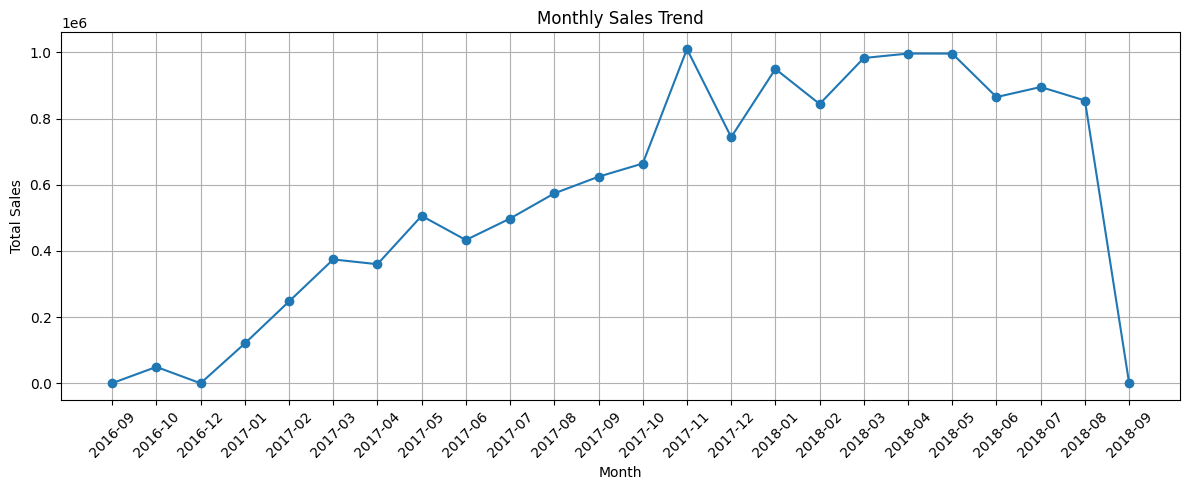

In [ ]:
import matplotlib.pyplot as plt

# Convert Spark DataFrame to Pandas for visualization
monthly_sales_pd = monthly_sales.toPandas()

# Create monthly sales trend
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_sales_pd["month"],
    monthly_sales_pd["total_sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Analyze orders by customer state

customer_orders = orders.join(
    customers.select("customer_id", "customer_state"),
    on="customer_id",
    how="inner"
)

state_analysis = customer_orders.groupBy("customer_state") \
    .count() \
    .orderBy("count", ascending=False)

state_analysis.show(10)

+--------------+-----+
|customer_state|count|
+--------------+-----+
|            SP|41746|
|            RJ|12852|
|            MG|11635|
|            RS| 5466|
|            PR| 5045|
|            SC| 3637|
|            BA| 3380|
|            DF| 2140|
|            ES| 2033|
|            GO| 2020|
+--------------+-----+
only showing top 10 rows


In [ ]:
# Analyze total spending by customer

customer_spending = order_items.join(
    orders.select("order_id", "customer_id"),
    on="order_id",
    how="inner"
)

customer_spending_analysis = customer_spending.groupBy("customer_id") \
    .agg(
        sum("price").alias("total_spending")
    ) \
    .orderBy("total_spending", ascending=False) \
    .limit(10)

customer_spending_analysis.show()

+--------------------+--------------+
|         customer_id|total_spending|
+--------------------+--------------+
|1617b1357756262bf...|       13440.0|
|ec5b2ba62e5743423...|        7160.0|
|c6e2731c5b391845f...|        6735.0|
|f48d464a0baaea338...|        6729.0|
|3fd6777bbce08a352...|        6499.0|
|05455dfa7cd02f13d...|        5934.6|
|df55c14d1476a9a34...|        4799.0|
|24bbf5fd2f2e1b359...|        4690.0|
|e0a2412720e9ea4f2...|        4599.9|
|3d979689f636322c6...|        4590.0|
+--------------------+--------------+



In [ ]:
from pyspark.sql.functions import unix_timestamp, avg, round

# Calculate delivery time in days
delivery_analysis = orders.filter(
    (orders.order_status == "delivered") &
    orders.order_purchase_timestamp.isNotNull() &
    orders.order_delivered_customer_date.isNotNull()
).withColumn(
    "delivery_days",
    (
        unix_timestamp("order_delivered_customer_date") -
        unix_timestamp("order_purchase_timestamp")
    ) / 86400
)

# Calculate average delivery time
average_delivery = delivery_analysis.agg(
    round(avg("delivery_days"), 2).alias("average_delivery_days")
)

average_delivery.show()

+---------------------+
|average_delivery_days|
+---------------------+
|                12.56|
+---------------------+



## Key Insights

1. The dataset contains approximately 99,441 orders and more than 112,000 order-item records, demonstrating the use of PySpark for large-scale data processing.

2. The majority of orders were successfully delivered, with 96,478 orders recorded as delivered.

3. Credit cards were the most frequently used payment method and also generated the highest total payment value.

4. The Health & Beauty category generated the highest sales value among the top-performing product categories analyzed.

5. São Paulo (SP) had the highest number of customer orders, followed by Rio de Janeiro (RJ) and Minas Gerais (MG).

6. The highest-spending customer in the analyzed data had a total purchase value of 13,440.

7. The average delivery time for delivered orders was approximately 12.56 days.

8. Monthly sales showed an overall increasing pattern across much of the available period, with variations between individual months.

## Conclusion

The analysis demonstrates how Apache PySpark can be used to process and analyze multiple large e-commerce datasets efficiently. By combining order, payment, product, customer, and delivery information, the project identified useful patterns in sales, customer behaviour, payment preferences, geographical distribution, and delivery performance.

These insights can help e-commerce businesses understand customer purchasing patterns, monitor product performance, evaluate payment preferences, and identify areas for improving delivery operations.

## Tools and Technologies Used

- **Python** – Programming and data analysis
- **Apache PySpark** – Large-scale data processing and analysis
- **Google Colab** – Development environment
- **Pandas** – Data conversion for visualization
- **Matplotlib** – Data visualization
- **Olist E-commerce Dataset** – Source dataset

## Project Outcome

This project demonstrates the use of Apache PySpark to process multiple interconnected e-commerce datasets and extract meaningful insights related to orders, payments, products, customers, sales trends, and delivery performance.